# EEG-to-Audio Reconstruction Demo

This is the single project notebook. It demonstrates both maintained reconstruction paths:

- **CNN baseline:** `DirectMelRegressor`, a convolutional EEG encoder plus mel decoder that maps EEG directly to a normalized log-mel spectrogram.
- **Latent diffusion model (LDM):** a spectrogram autoencoder plus an EEG-conditioned DDPM denoiser trained in normalized latent space.

The notebook starts from MAD-EEG windows, builds mel features, checks autoencoder reconstruction, compares CNN and LDM predictions, and exports listenable WAV files.


In [1]:
from __future__ import annotations

from dataclasses import asdict
from pathlib import Path
import json
import subprocess
import sys
import time

import numpy as np
import torch
import torch.nn.functional as F
import torchaudio
import matplotlib.pyplot as plt

try:
    from IPython.display import Audio, display
except ImportError:
    Audio = None

    def display(value):
        print(value)


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
            return candidate
    raise RuntimeError("Could not locate the project root.")


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from eeg_audio_reconstruction.config import DiffusionConfig, FeatureConfig, load_yaml
from eeg_audio_reconstruction.data import MADEEGDataset
from eeg_audio_reconstruction.diffusion import DiffusionSchedule
from eeg_audio_reconstruction.features import LogMelExtractor
from eeg_audio_reconstruction.latent import denormalize_latent, normalize_latent
from eeg_audio_reconstruction.models import ConditionalLatentDenoiser, DirectMelRegressor, SpectrogramAutoencoder
from eeg_audio_reconstruction.train_utils import count_parameters, get_device, load_checkpoint, save_checkpoint, seed_everything
from eeg_audio_reconstruction.visualization import save_mel_image

seed_everything(42)
device = get_device("auto")
plt.rcParams["figure.dpi"] = 120

print(f"Project root: {PROJECT_ROOT}")
print(f"Device: {device}")


Project root: C:\Users\jlama\eeg2audio
Device: cuda


## Paths and Configuration

The full training configuration lives in `configs/ldm.yaml`. The quick demo cache uses the same model family but fewer diffusion blocks and a single sample so the notebook can prove the pipeline without launching a long experiment.


In [2]:
DATA_HDF5 = PROJECT_ROOT / "data" / "madeeg_preprocessed.hdf5"
METADATA_YAML = PROJECT_ROOT / "data" / "madeeg_preprocessed.yaml"
CONFIG_PATH = PROJECT_ROOT / "configs" / "ldm.yaml"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "notebook_demo"

FULL_AUTOENCODER_PATH = CHECKPOINT_DIR / "autoencoder.pt"
FULL_LDM_PATH = CHECKPOINT_DIR / "ldm.pt"
FULL_CNN_PATH = CHECKPOINT_DIR / "baseline.pt"

DEMO_AUTOENCODER_PATH = CHECKPOINT_DIR / "notebook_demo_v2_autoencoder.pt"
DEMO_LDM_PATH = CHECKPOINT_DIR / "notebook_demo_v2_ldm.pt"
DEMO_CNN_PATH = CHECKPOINT_DIR / "notebook_demo_v2_cnn.pt"
DEMO_VERSION = "latent_stats_schedule_v2"

SAMPLE_INDEX = 0
FORCE_RETRAIN_DEMO = False

if not DATA_HDF5.exists():
    raise FileNotFoundError(f"Missing local dataset: {DATA_HDF5}")
if not METADATA_YAML.exists():
    raise FileNotFoundError(f"Missing metadata YAML: {METADATA_YAML}")

print(json.dumps(load_yaml(CONFIG_PATH), indent=2))


{
  "data": {
    "hdf5_path": "data/madeeg_preprocessed.hdf5",
    "metadata_path": "data/madeeg_preprocessed.yaml",
    "segment_seconds": 1.0,
    "average_repetitions": 4,
    "target": "stimulus"
  },
  "features": {
    "sample_rate": 16000,
    "n_fft": 1024,
    "hop_length": 256,
    "n_mels": 128,
    "frames": 64
  },
  "autoencoder": {
    "latent_channels": 8,
    "base_channels": 32
  },
  "diffusion": {
    "timesteps": 100,
    "beta_start": 0.0001,
    "beta_end": 0.02,
    "target_alpha_bar": 0.001
  },
  "denoiser": {
    "model_channels": 96,
    "cond_dim": 256,
    "num_res_blocks": 6
  },
  "training": {
    "autoencoder_epochs": 20,
    "ldm_epochs": 40,
    "batch_size": 16,
    "autoencoder_lr": 0.0002,
    "ldm_lr": 0.0001
  }
}


## Dataset Window

`MADEEGDataset` lazily indexes one-second EEG/audio windows. Each item contains normalized EEG, a target waveform, sample-rate metadata, and subject/stimulus identifiers.


In [3]:
dataset = MADEEGDataset(hdf5_path=DATA_HDF5, metadata_path=METADATA_YAML, split="all")
description = dataset.describe()
description


{'samples': 1395,
 'subjects': 8,
 'stimuli': 63,
 'hours': 0.3875,
 'target': 'stimulus',
 'split': 'all'}

In [4]:
sample = dataset[SAMPLE_INDEX]
source_sr = int(sample["audio_sample_rate"])
eeg = sample["eeg"].unsqueeze(0).to(device)
audio = sample["audio"].unsqueeze(0).to(device)

print(f"Subject: {sample['subject']}")
print(f"Stimulus: {sample['stimulus']}")
print(f"Segment index: {sample['segment_index']}")
print(f"EEG tensor: {tuple(eeg.shape)}")
print(f"Audio tensor: {tuple(audio.shape)} at {source_sr} Hz")


Subject: 0001
Stimulus: classique_morceau1_duo_CoFl_theme1_stereo_Co
Segment index: 0
EEG tensor: (1, 20, 256)
Audio tensor: (1, 1, 44100) at 44100 Hz


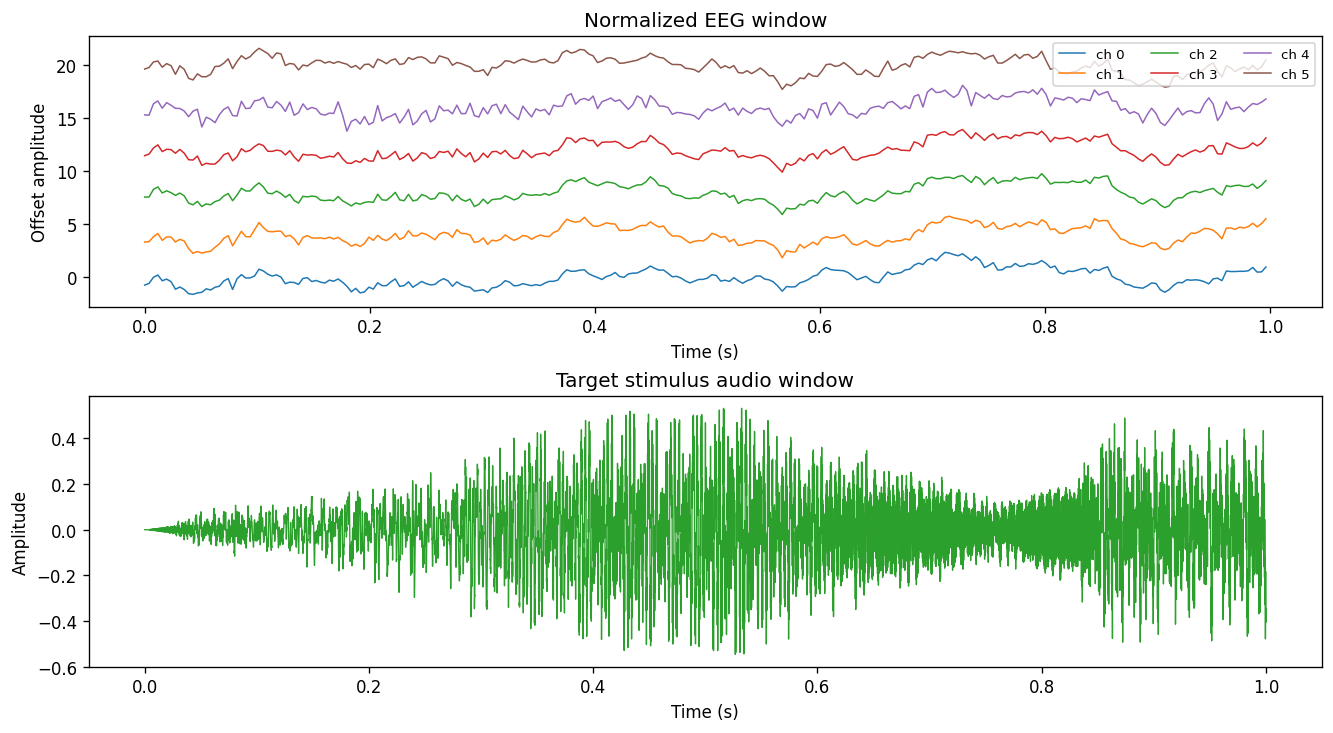

In [5]:
eeg_np = sample["eeg"].numpy()
audio_np = sample["audio"].squeeze(0).numpy()
eeg_time = np.arange(eeg_np.shape[-1]) / 256.0
audio_time = np.arange(audio_np.shape[-1]) / source_sr

fig, axes = plt.subplots(2, 1, figsize=(11, 6), constrained_layout=True)
for channel in range(min(6, eeg_np.shape[0])):
    axes[0].plot(eeg_time, eeg_np[channel] + channel * 4.0, linewidth=0.9, label=f"ch {channel}")
axes[0].set_title("Normalized EEG window")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Offset amplitude")
axes[0].legend(ncol=3, fontsize=8, loc="upper right")

axes[1].plot(audio_time, audio_np, linewidth=0.8, color="tab:green")
axes[1].set_title("Target stimulus audio window")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Amplitude")
plt.show()


## Feature Space

All models operate on normalized log-mel spectrograms. The output range is `[-1, 1]`, where `1` is the local spectral peak and `-1` is `top_db` below that peak.


FeatureConfig(sample_rate=16000, n_fft=1024, hop_length=256, n_mels=128, frames=64, f_min=20.0, f_max=None, top_db=80.0)
Target mel tensor: (1, 1, 128, 64)


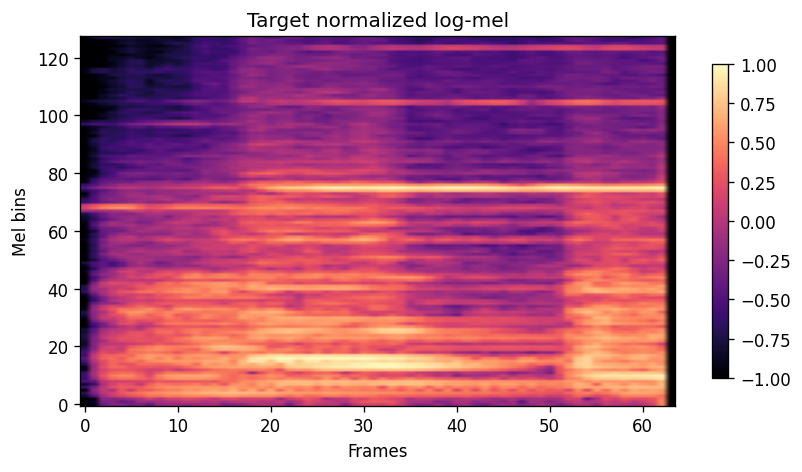

In [6]:
feature_config = FeatureConfig()
extractor = LogMelExtractor(feature_config).to(device)

with torch.no_grad():
    target_mel = extractor(audio, source_sr)

print(feature_config)
print(f"Target mel tensor: {tuple(target_mel.shape)}")

fig, ax = plt.subplots(figsize=(8, 4))
image = ax.imshow(target_mel[0, 0].detach().cpu(), origin="lower", aspect="auto", cmap="magma", vmin=-1, vmax=1)
ax.set_title("Target normalized log-mel")
ax.set_xlabel("Frames")
ax.set_ylabel("Mel bins")
fig.colorbar(image, ax=ax, shrink=0.85)
plt.show()


## Load Full Models or Train a Fast Demo Cache

Full checkpoints are used when all three exist. Otherwise, the notebook trains a small cached demo on the selected sample. This is an overfit sanity demo, not a claim of held-out generalization. Its job is to verify that the CNN, autoencoder, and LDM paths can produce non-collapsed reconstructions.


In [7]:
def checkpoint_has_demo_version(path: Path) -> bool:
    if not path.exists():
        return False
    try:
        checkpoint = load_checkpoint(path, map_location="cpu")
    except Exception:
        return False
    return checkpoint.get("demo_version") == DEMO_VERSION


def make_latent_stats(latent: torch.Tensor) -> dict:
    return {
        "mean": latent.mean(dim=(0, 2, 3)).detach().cpu().tolist(),
        "std": latent.std(dim=(0, 2, 3)).clamp_min(1e-6).detach().cpu().tolist(),
        "eps": 1e-6,
        "count": int(latent.shape[0] * latent.shape[2] * latent.shape[3]),
    }


def train_demo_checkpoints() -> tuple[Path, Path, Path, str]:
    full_paths = [FULL_AUTOENCODER_PATH, FULL_LDM_PATH, FULL_CNN_PATH]
    if all(path.exists() for path in full_paths):
        return FULL_AUTOENCODER_PATH, FULL_LDM_PATH, FULL_CNN_PATH, "full checkpoints"

    demo_paths = [DEMO_AUTOENCODER_PATH, DEMO_LDM_PATH, DEMO_CNN_PATH]
    if not FORCE_RETRAIN_DEMO and all(checkpoint_has_demo_version(path) for path in demo_paths):
        return DEMO_AUTOENCODER_PATH, DEMO_LDM_PATH, DEMO_CNN_PATH, "cached notebook demo checkpoints"

    print("Training notebook demo checkpoints. This is a fast overfit sanity check.")
    CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

    demo_eeg = eeg.detach()
    demo_mel = target_mel.detach()
    ae_config = {"latent_channels": 8, "base_channels": 32}
    denoiser_config = {"model_channels": 32, "cond_dim": 256, "num_res_blocks": 2}
    diffusion_config = {"timesteps": 64, "beta_start": 1e-4, "beta_end": 0.02, "target_alpha_bar": 1e-3}

    ae_steps = 500 if device.type == "cuda" else 160
    cnn_steps = 600 if device.type == "cuda" else 180
    ldm_steps = 2000 if device.type == "cuda" else 320

    autoencoder = SpectrogramAutoencoder(
        n_mels=feature_config.n_mels,
        frames=feature_config.frames,
        **ae_config,
    ).to(device)
    optimizer = torch.optim.AdamW(autoencoder.parameters(), lr=2e-3)
    start = time.perf_counter()
    for step in range(1, ae_steps + 1):
        reconstruction = autoencoder(demo_mel)
        loss = F.l1_loss(reconstruction, demo_mel) + 0.5 * F.mse_loss(reconstruction, demo_mel)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        if step in {1, ae_steps} or step % max(ae_steps // 4, 1) == 0:
            print(f"AE step {step:04d}/{ae_steps} | loss={loss.item():.4f}")

    autoencoder.eval().requires_grad_(False)
    with torch.no_grad():
        clean_latent = autoencoder.encode(demo_mel)
    latent_stats = make_latent_stats(clean_latent)
    normalized_latent = normalize_latent(clean_latent, latent_stats).detach()
    save_checkpoint(
        DEMO_AUTOENCODER_PATH,
        epoch=ae_steps,
        loss=float(loss.item()),
        model_state=autoencoder.state_dict(),
        model_config=ae_config,
        feature_config=asdict(feature_config),
        demo_version=DEMO_VERSION,
    )
    print(f"AE training time: {time.perf_counter() - start:.1f}s")

    cnn = DirectMelRegressor(n_mels=feature_config.n_mels, frames=feature_config.frames).to(device)
    optimizer = torch.optim.AdamW(cnn.parameters(), lr=2e-3)
    start = time.perf_counter()
    for step in range(1, cnn_steps + 1):
        prediction = cnn(demo_eeg)
        loss = F.l1_loss(prediction, demo_mel) + 0.5 * F.mse_loss(prediction, demo_mel)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        if step in {1, cnn_steps} or step % max(cnn_steps // 4, 1) == 0:
            print(f"CNN step {step:04d}/{cnn_steps} | loss={loss.item():.4f}")
    save_checkpoint(
        DEMO_CNN_PATH,
        epoch=cnn_steps,
        loss=float(loss.item()),
        model_state=cnn.state_dict(),
        feature_config=asdict(feature_config),
        demo_version=DEMO_VERSION,
    )
    print(f"CNN training time: {time.perf_counter() - start:.1f}s")

    denoiser = ConditionalLatentDenoiser(latent_channels=autoencoder.latent_channels, **denoiser_config).to(device)
    schedule = DiffusionSchedule(**diffusion_config).to(device)
    optimizer = torch.optim.AdamW(denoiser.parameters(), lr=1e-3)
    start = time.perf_counter()
    for step in range(1, ldm_steps + 1):
        noise = torch.randn_like(normalized_latent)
        timesteps = torch.randint(0, schedule.timesteps, (normalized_latent.shape[0],), device=device)
        noisy_latent = schedule.q_sample(normalized_latent, timesteps, noise)
        predicted_noise = denoiser(noisy_latent, timesteps, demo_eeg)
        loss = F.mse_loss(predicted_noise, noise)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(denoiser.parameters(), 1.0)
        optimizer.step()
        if step in {1, ldm_steps} or step % max(ldm_steps // 4, 1) == 0:
            print(f"LDM step {step:04d}/{ldm_steps} | noise_mse={loss.item():.4f}")
    save_checkpoint(
        DEMO_LDM_PATH,
        epoch=ldm_steps,
        loss=float(loss.item()),
        model_state=denoiser.state_dict(),
        model_config=denoiser_config,
        diffusion_config=diffusion_config,
        feature_config=asdict(feature_config),
        autoencoder_config=ae_config,
        latent_shape=autoencoder.latent_shape,
        latent_stats=latent_stats,
        demo_version=DEMO_VERSION,
    )
    print(f"LDM training time: {time.perf_counter() - start:.1f}s")
    return DEMO_AUTOENCODER_PATH, DEMO_LDM_PATH, DEMO_CNN_PATH, "fresh notebook demo checkpoints"


AUTOENCODER_PATH, LDM_PATH, CNN_PATH, checkpoint_source = train_demo_checkpoints()
print(f"Using {checkpoint_source}:")
print(f"  autoencoder: {AUTOENCODER_PATH}")
print(f"  LDM:         {LDM_PATH}")
print(f"  CNN:         {CNN_PATH}")


Using cached notebook demo checkpoints:
  autoencoder: C:\Users\jlama\eeg2audio\checkpoints\notebook_demo_v2_autoencoder.pt
  LDM:         C:\Users\jlama\eeg2audio\checkpoints\notebook_demo_v2_ldm.pt
  CNN:         C:\Users\jlama\eeg2audio\checkpoints\notebook_demo_v2_cnn.pt


## Instantiate the CNN and LDM Models

The CNN baseline predicts mel spectrograms directly from EEG. The LDM first reconstructs/encodes mel spectrograms with the autoencoder, denoises normalized latents conditioned on EEG, then decodes the sampled latent back to mel space.


In [8]:
ae_checkpoint = load_checkpoint(AUTOENCODER_PATH, map_location=device)
feature_config = FeatureConfig(**ae_checkpoint["feature_config"])
extractor = LogMelExtractor(feature_config).to(device)

with torch.no_grad():
    target_mel = extractor(audio, source_sr)

autoencoder = SpectrogramAutoencoder(
    n_mels=feature_config.n_mels,
    frames=feature_config.frames,
    **ae_checkpoint["model_config"],
).to(device)
autoencoder.load_state_dict(ae_checkpoint["model_state"])
autoencoder.eval().requires_grad_(False)

cnn_checkpoint = load_checkpoint(CNN_PATH, map_location=device)
cnn = DirectMelRegressor(n_mels=feature_config.n_mels, frames=feature_config.frames).to(device)
cnn.load_state_dict(cnn_checkpoint["model_state"])
cnn.eval().requires_grad_(False)

ldm_checkpoint = load_checkpoint(LDM_PATH, map_location=device)
denoiser = ConditionalLatentDenoiser(
    latent_channels=autoencoder.latent_channels,
    **ldm_checkpoint["model_config"],
).to(device)
denoiser.load_state_dict(ldm_checkpoint["model_state"])
denoiser.eval().requires_grad_(False)

schedule = DiffusionSchedule(**ldm_checkpoint["diffusion_config"]).to(device)
latent_shape = tuple(ldm_checkpoint.get("latent_shape", autoencoder.latent_shape))
latent_stats = ldm_checkpoint.get("latent_stats")

print(f"Autoencoder parameters: {count_parameters(autoencoder, trainable_only=False):,}")
print(f"CNN parameters: {count_parameters(cnn, trainable_only=False):,}")
print(f"Denoiser parameters: {count_parameters(denoiser, trainable_only=False):,}")
print(f"Latent shape: {latent_shape}")
print(f"Terminal alpha_bar: {float(schedule.alpha_bars[-1]):.6f}")
if latent_stats is None:
    print("No latent stats found; this is a legacy LDM checkpoint and may sample poorly.")
else:
    print("Latent stats are present for normalized diffusion sampling.")


Autoencoder parameters: 355,369
CNN parameters: 9,654,529
Denoiser parameters: 947,624
Latent shape: (8, 16, 8)
Terminal alpha_bar: 0.001000
Latent stats are present for normalized diffusion sampling.


## Autoencoder Reconstruction Check

This is the first quality gate. If this is flat, the LDM cannot work because it decodes through this model. A healthy reconstruction should preserve visible time-frequency structure.


Encoded latent tensor: (1, 8, 16, 8)
Raw latent std: 2.0104
Normalized latent std: 0.9966
Autoencoder reconstruction L1: 0.0096
Autoencoder reconstruction MSE: 0.0002


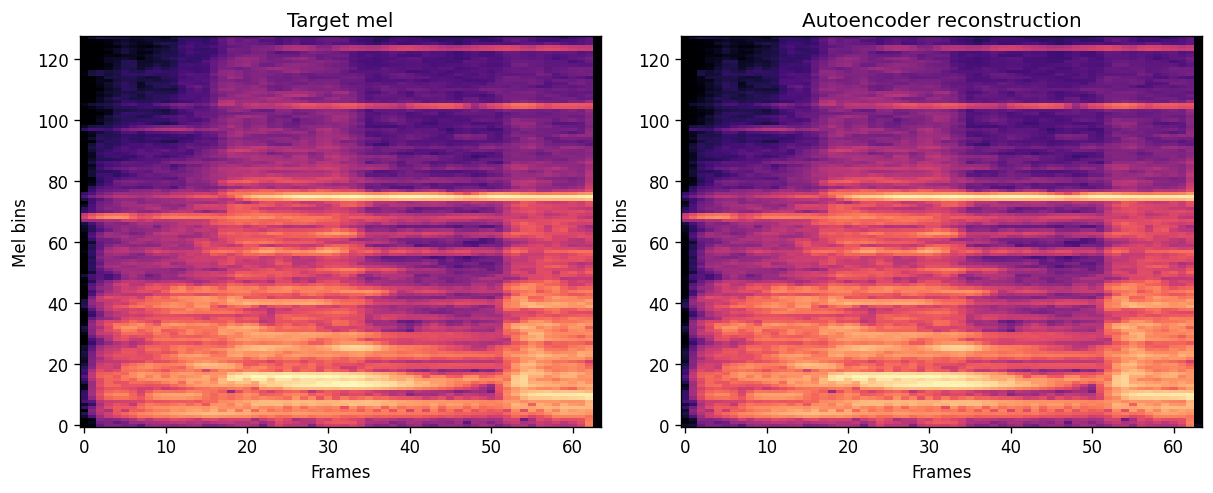

In [9]:
with torch.no_grad():
    encoded_latent = autoencoder.encode(target_mel)
    normalized_encoded_latent = normalize_latent(encoded_latent, latent_stats)
    autoencoded_mel = autoencoder.decode(encoded_latent).clamp(-1.0, 1.0)

ae_l1 = F.l1_loss(autoencoded_mel, target_mel).item()
ae_mse = F.mse_loss(autoencoded_mel, target_mel).item()
print(f"Encoded latent tensor: {tuple(encoded_latent.shape)}")
print(f"Raw latent std: {encoded_latent.std().item():.4f}")
print(f"Normalized latent std: {normalized_encoded_latent.std().item():.4f}")
print(f"Autoencoder reconstruction L1: {ae_l1:.4f}")
print(f"Autoencoder reconstruction MSE: {ae_mse:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
for ax, mel, title in [
    (axes[0], target_mel, "Target mel"),
    (axes[1], autoencoded_mel, "Autoencoder reconstruction"),
]:
    ax.imshow(mel[0, 0].detach().cpu(), origin="lower", aspect="auto", cmap="magma", vmin=-1, vmax=1)
    ax.set_title(title)
    ax.set_xlabel("Frames")
    ax.set_ylabel("Mel bins")
plt.show()


## CNN Baseline Prediction

The CNN baseline is deterministic: EEG goes in, a mel spectrogram comes out. It is useful as a direct reconstruction reference beside the generative LDM path.


In [10]:
with torch.no_grad():
    cnn_mel = cnn(eeg).clamp(-1.0, 1.0)

cnn_l1 = F.l1_loss(cnn_mel, target_mel).item()
cnn_mse = F.mse_loss(cnn_mel, target_mel).item()
print(f"CNN prediction tensor: {tuple(cnn_mel.shape)}")
print(f"CNN prediction std: {cnn_mel.std().item():.4f}")
print(f"CNN vs target L1: {cnn_l1:.4f}")
print(f"CNN vs target MSE: {cnn_mse:.4f}")


CNN prediction tensor: (1, 1, 128, 64)
CNN prediction std: 0.4248
CNN vs target L1: 0.0082
CNN vs target MSE: 0.0001


## LDM Noise-Prediction Objective

This is the training objective used by `scripts/train_ldm.py`: normalize the clean autoencoder latent, add scheduled Gaussian noise, and ask the EEG-conditioned denoiser to predict that noise.


In [11]:
with torch.no_grad():
    clean_latent = normalize_latent(autoencoder.encode(target_mel), latent_stats)
    noise = torch.randn_like(clean_latent)
    timesteps = torch.randint(0, schedule.timesteps, (clean_latent.shape[0],), device=device)
    noisy_latent = schedule.q_sample(clean_latent, timesteps, noise)
    predicted_noise = denoiser(noisy_latent, timesteps, eeg)
    diffusion_objective_mse = F.mse_loss(predicted_noise, noise).item()

print(f"Timestep sampled: {int(timesteps[0].item())}")
print(f"Clean normalized latent: {tuple(clean_latent.shape)}")
print(f"Noisy latent: {tuple(noisy_latent.shape)}")
print(f"Predicted noise: {tuple(predicted_noise.shape)}")
print(f"Noise-prediction MSE for this sample: {diffusion_objective_mse:.4f}")


Timestep sampled: 39
Clean normalized latent: (1, 8, 16, 8)
Noisy latent: (1, 8, 16, 8)
Predicted noise: (1, 8, 16, 8)
Noise-prediction MSE for this sample: 0.0294


## EEG-Conditioned LDM Sampling

The reverse process starts from Gaussian noise in normalized latent space. For reconstruction, the demo uses deterministic posterior-mean sampling so the EEG-to-audio output is stable instead of adding extra random variation at every reverse step.


In [12]:
seed_everything(7)
start = time.perf_counter()
with torch.no_grad():
    sampled_normalized_latent = schedule.sample(
        denoiser,
        eeg=eeg,
        shape=(1, *latent_shape),
        device=device,
        stochastic=False,
    )
    sampled_latent = denormalize_latent(sampled_normalized_latent, latent_stats)
    ldm_mel = autoencoder.decode(sampled_latent).clamp(-1.0, 1.0)
elapsed = time.perf_counter() - start

ldm_l1 = F.l1_loss(ldm_mel, target_mel).item()
ldm_mse = F.mse_loss(ldm_mel, target_mel).item()
print(f"Sampled normalized latent std: {sampled_normalized_latent.std().item():.4f}")
print(f"Decoded LDM mel std: {ldm_mel.std().item():.4f}")
print(f"Sampling time: {elapsed:.2f} seconds")
print(f"LDM vs target L1: {ldm_l1:.4f}")
print(f"LDM vs target MSE: {ldm_mse:.4f}")


Sampled normalized latent std: 0.8940
Decoded LDM mel std: 0.4039
Sampling time: 0.20 seconds
LDM vs target L1: 0.1301
LDM vs target MSE: 0.0505


## Side-by-Side Comparison

The important visual check is that none of the predictions collapse to a flat average image. The autoencoder is the reconstruction ceiling for this pipeline, while the CNN and LDM show two different EEG-conditioned approaches.


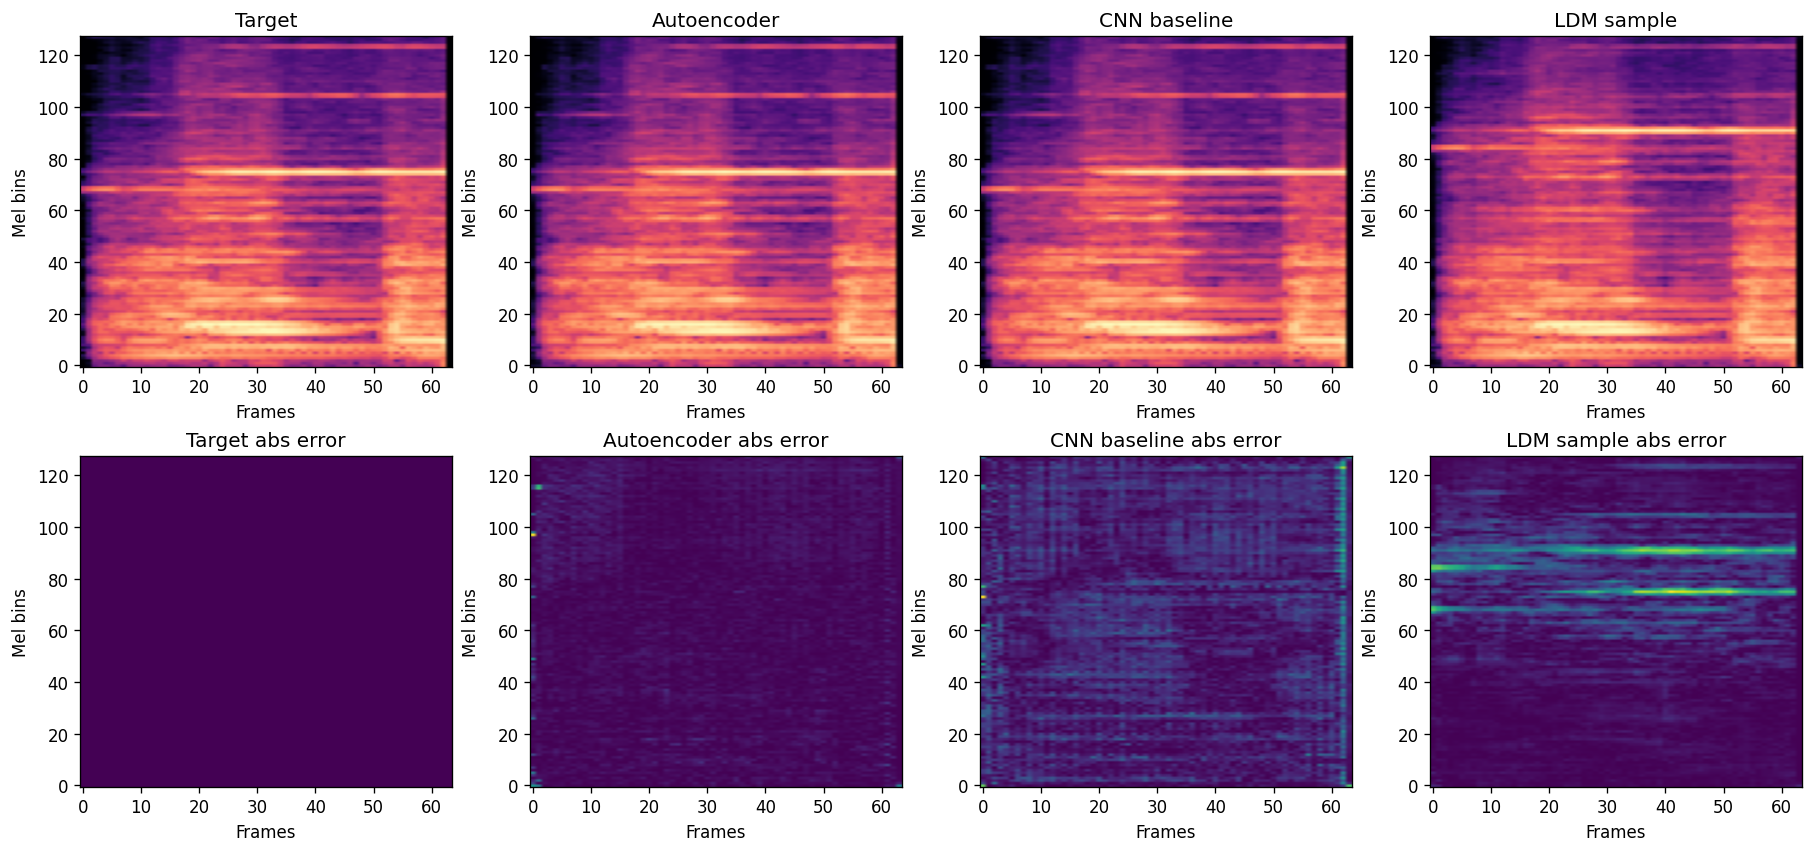

{'autoencoder_l1': 0.009568292647600174,
 'cnn_l1': 0.008188199251890182,
 'ldm_l1': 0.13012203574180603,
 'autoencoder_std': 0.43237507343292236,
 'cnn_std': 0.4247846007347107,
 'ldm_std': 0.40387409925460815}

In [13]:
comparison = [
    ("Target", target_mel),
    ("Autoencoder", autoencoded_mel),
    ("CNN baseline", cnn_mel),
    ("LDM sample", ldm_mel),
]

fig, axes = plt.subplots(2, 4, figsize=(15, 7), constrained_layout=True)
for col, (title, mel) in enumerate(comparison):
    axes[0, col].imshow(mel[0, 0].detach().cpu(), origin="lower", aspect="auto", cmap="magma", vmin=-1, vmax=1)
    axes[0, col].set_title(title)
    axes[0, col].set_xlabel("Frames")
    axes[0, col].set_ylabel("Mel bins")

    if title == "Target":
        error = torch.zeros_like(target_mel[0, 0])
    else:
        error = (mel[0, 0] - target_mel[0, 0]).abs()
    vmax = float(error.max().detach().cpu().clamp_min(1e-6))
    axes[1, col].imshow(error.detach().cpu(), origin="lower", aspect="auto", cmap="viridis", vmin=0, vmax=vmax)
    axes[1, col].set_title(f"{title} abs error")
    axes[1, col].set_xlabel("Frames")
    axes[1, col].set_ylabel("Mel bins")
plt.show()

metrics = {
    "autoencoder_l1": ae_l1,
    "cnn_l1": cnn_l1,
    "ldm_l1": ldm_l1,
    "autoencoder_std": float(autoencoded_mel.std().item()),
    "cnn_std": float(cnn_mel.std().item()),
    "ldm_std": float(ldm_mel.std().item()),
}
metrics


## Export Audio and Figures

The waveform reconstruction uses inverse mel scaling plus Griffin-Lim. That keeps the demo dependency-light; a neural vocoder could replace this later.


In [14]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
mel_outputs = {
    "target": target_mel,
    "autoencoder": autoencoded_mel,
    "cnn": cnn_mel,
    "ldm": ldm_mel,
}

written_files = []
for name, mel in mel_outputs.items():
    image_path = OUTPUT_DIR / f"{name}_mel.png"
    save_mel_image(mel, image_path, title=f"{name} mel")
    written_files.append(image_path)

    if name == "target":
        wav_path = OUTPUT_DIR / "target.wav"
        torchaudio.save(str(wav_path), sample["audio"].cpu(), source_sr)
    else:
        with torch.no_grad():
            waveform = extractor.mel_to_waveform(mel).cpu()
        wav_path = OUTPUT_DIR / f"{name}.wav"
        torchaudio.save(str(wav_path), waveform[0], feature_config.sample_rate)
    written_files.append(wav_path)

reconstruction_path = OUTPUT_DIR / "reconstruction.pt"
torch.save(
    {
        "sample_index": SAMPLE_INDEX,
        "subject": sample["subject"],
        "stimulus": sample["stimulus"],
        "metrics": metrics,
        "target_mel": target_mel.cpu(),
        "autoencoder_mel": autoencoded_mel.cpu(),
        "cnn_mel": cnn_mel.cpu(),
        "ldm_mel": ldm_mel.cpu(),
        "autoencoder_checkpoint": str(AUTOENCODER_PATH),
        "ldm_checkpoint": str(LDM_PATH),
        "cnn_checkpoint": str(CNN_PATH),
    },
    reconstruction_path,
)
written_files.append(reconstruction_path)

for path in written_files:
    print(f"Wrote: {path}")

if Audio is not None:
    for name in ["target", "autoencoder", "cnn", "ldm"]:
        print(name)
        display(Audio(filename=str(OUTPUT_DIR / f"{name}.wav")))


Wrote: C:\Users\jlama\eeg2audio\outputs\notebook_demo\target_mel.png
Wrote: C:\Users\jlama\eeg2audio\outputs\notebook_demo\target.wav
Wrote: C:\Users\jlama\eeg2audio\outputs\notebook_demo\autoencoder_mel.png
Wrote: C:\Users\jlama\eeg2audio\outputs\notebook_demo\autoencoder.wav
Wrote: C:\Users\jlama\eeg2audio\outputs\notebook_demo\cnn_mel.png
Wrote: C:\Users\jlama\eeg2audio\outputs\notebook_demo\cnn.wav
Wrote: C:\Users\jlama\eeg2audio\outputs\notebook_demo\ldm_mel.png
Wrote: C:\Users\jlama\eeg2audio\outputs\notebook_demo\ldm.wav
Wrote: C:\Users\jlama\eeg2audio\outputs\notebook_demo\reconstruction.pt
target


autoencoder


cnn


ldm


## Full Training Commands

The cached notebook demo is intentionally small. Use the commands below for real training over the dataset.


In [15]:
training_commands = [
    [
        sys.executable,
        str(PROJECT_ROOT / "scripts" / "train_autoencoder.py"),
        "--epochs", "20",
        "--batch-size", "16",
        "--output", str(FULL_AUTOENCODER_PATH),
    ],
    [
        sys.executable,
        str(PROJECT_ROOT / "scripts" / "train_ldm.py"),
        "--autoencoder", str(FULL_AUTOENCODER_PATH),
        "--epochs", "40",
        "--batch-size", "16",
        "--output", str(FULL_LDM_PATH),
        "--target-alpha-bar", "0.001",
    ],
    [
        sys.executable,
        str(PROJECT_ROOT / "scripts" / "train_baseline.py"),
        "--epochs", "30",
        "--batch-size", "16",
        "--output", str(FULL_CNN_PATH),
    ],
    [
        sys.executable,
        str(PROJECT_ROOT / "scripts" / "reconstruct.py"),
        "--method", "ldm",
        "--autoencoder", str(FULL_AUTOENCODER_PATH),
        "--ldm", str(FULL_LDM_PATH),
        "--sample-index", str(SAMPLE_INDEX),
        "--output-dir", str(PROJECT_ROOT / "outputs" / "reconstruction"),
    ],
]

for command in training_commands:
    print(" ".join(f'"{part}"' if " " in part else part for part in command))


c:\Users\jlama\eeg2audio\.env\Scripts\python.exe C:\Users\jlama\eeg2audio\scripts\train_autoencoder.py --epochs 20 --batch-size 16 --output C:\Users\jlama\eeg2audio\checkpoints\autoencoder.pt
c:\Users\jlama\eeg2audio\.env\Scripts\python.exe C:\Users\jlama\eeg2audio\scripts\train_ldm.py --autoencoder C:\Users\jlama\eeg2audio\checkpoints\autoencoder.pt --epochs 40 --batch-size 16 --output C:\Users\jlama\eeg2audio\checkpoints\ldm.pt --target-alpha-bar 0.001
c:\Users\jlama\eeg2audio\.env\Scripts\python.exe C:\Users\jlama\eeg2audio\scripts\train_baseline.py --epochs 30 --batch-size 16 --output C:\Users\jlama\eeg2audio\checkpoints\baseline.pt
c:\Users\jlama\eeg2audio\.env\Scripts\python.exe C:\Users\jlama\eeg2audio\scripts\reconstruct.py --method ldm --autoencoder C:\Users\jlama\eeg2audio\checkpoints\autoencoder.pt --ldm C:\Users\jlama\eeg2audio\checkpoints\ldm.pt --sample-index 0 --output-dir C:\Users\jlama\eeg2audio\outputs\reconstruction


In [16]:
RUN_FULL_TRAINING = False

if RUN_FULL_TRAINING:
    for command in training_commands:
        subprocess.run(command, cwd=PROJECT_ROOT, check=True)
else:
    print("Full training skipped. Set RUN_FULL_TRAINING = True when you want to launch the long training workflow.")


Full training skipped. Set RUN_FULL_TRAINING = True when you want to launch the long training workflow.


In [17]:
dataset.close()
print("Demo complete.")


Demo complete.
